# Task 3 — Portfolio Sorting & Quintile Portfolios

**Week 2, Task 3** — forms quintile portfolios from the value proxy and momentum
signals built in Tasks 1 and 2.

## What this notebook does
1. Builds forward holding-period returns via `build_forward_returns()`.
2. Joins forward returns to both score tables.
3. Calls `form_quintile_portfolios()` once for value, once for momentum.
4. Verifies bucket sizes at the 51-ticker and 50-ticker rebalance dates.
5. Manual no-look-ahead spot-check (score formation date vs. forward return period).
6. PLTR sanity check: confirms Q5 on momentum, Q1 on value.
7. Monthly return summary for Q1–Q5 on both factors.

## Quintile convention
Both signals are oriented so **higher = more desirable**  
(value proxy: higher = cheaper; momentum: higher = stronger winner).  
This notebook uses a single uniform sort: **Q5 = top score = most desirable,
Q1 = bottom score = least desirable**. No sign flip needed for either factor.

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

from data_utils import load_ohlcv, clean_ohlcv, resample_ohlcv
from factor_utils import (
    compute_value_score,
    compute_momentum_score,
    build_forward_returns,
    form_quintile_portfolios,
)
from universe import UNIVERSE, START_DATE, END_DATE

pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams["figure.dpi"] = 120

## 1 · Load and clean data

In [2]:
daily = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)

print(f"Rows: {len(cleaned):,}  |  Tickers: {cleaned['ticker'].nunique()}  "
      f"|  Range: {cleaned['date'].min().date()} → {cleaned['date'].max().date()}")

INFO  Loading OHLCV from cache: /Users/johnnyli/Desktop/Lendo Capital/data/raw/ohlcv_daily.parquet


INFO  No within-life gaps to fill — data is complete.


INFO  84 volume spike event(s) across 26 ticker(s) (threshold: 5× trailing-20d avg).


Rows: 64,035  |  Tickers: 51  |  Range: 2020-08-31 → 2025-08-29


## 2 · Compute factor scores

In [3]:
val = compute_value_score(cleaned)
mom = compute_momentum_score(cleaned)

print(f"Value scores  : {len(val):,} rows, {val['date'].nunique()} rebalance dates")
print(f"Momentum scores: {len(mom):,} rows, {mom['date'].nunique()} rebalance dates")

INFO  Rebalance dates: 61 month-ends (2020-08-31 → 2025-08-31)


INFO  Excluded 51/51 tickers — only 0 months of data before 2020-08-31 (need 12); earliest monthly bar is 2020-08-31 (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51/51 tickers — only 1 months of data before 2020-09-30 (need 12); earliest monthly bar is 2020-08-31 (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51/51 tickers — only 2 months of data before 2020-10-31 (need 12); earliest monthly bar is 2020-08-31 (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51/51 tickers — only 3 months of data before 2020-11-30 (need 12); earliest monthly bar is 2020-08-31 (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


...

INFO  Excluded 51/51 tickers — only 10 months of data before 2021-06-30 (need 12); universe-wide lockout (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51/51 tickers — only 11 months of data before 2021-07-31 (need 12); universe-wide lockout (showing 5 of 51): ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 1/51 tickers — NaN price at 2020-08-31 or 2021-07-31 for PLTR (IPO or data gap within window) (showing 1 of 1): ['PLTR']


INFO  compute_momentum_score: 2498 records across 49 rebalance dates, 51 tickers (lookback=12, skip=1 months)


Value scores  : 2,498 rows, 49 rebalance dates
Momentum scores: 2,498 rows, 49 rebalance dates


## 3 · Build forward holding-period returns

**Forward return at rebalance date `t`** = return earned holding from `t` to `t+1`
= `adj_close_{t+1} / adj_close_t − 1`.

Implementation: `compute_returns(monthly, method="simple")` produces returns
indexed at the date they end (i.e. the value at `t+1` is the return from `t`
to `t+1`). `shift(-1)` per ticker pulls that value back to row `t`, so each
rebalance date stores the return it will earn going forward — not the return
already used to build the signal.

The last rebalance date (2025-08-31) has no subsequent monthly bar → NaN,
excluded by `form_quintile_portfolios` with a logged reason.

In [4]:
fwd = build_forward_returns(cleaned)

n_nan_dates = fwd[fwd["fwd_return"].isna()]["date"].nunique()
nan_dates   = fwd[fwd["fwd_return"].isna()]["date"].unique()

print(f"Forward return rows : {len(fwd):,}")
print(f"Rows with NaN fwd_return: {fwd['fwd_return'].isna().sum()} "
      f"across {n_nan_dates} date(s): {[str(d.date()) for d in sorted(nan_dates)]}")
print("(NaN = last month-end per ticker — no subsequent month to earn a return)")

INFO  build_forward_returns: 3110 rows, 51 with fwd_return=NaN (last month-end per ticker, expected 51)


Forward return rows : 3,110
Rows with NaN fwd_return: 51 across 1 date(s): ['2025-08-31']
(NaN = last month-end per ticker — no subsequent month to earn a return)


## 4 · Join forward returns to score tables

In [5]:
val_j = val.merge(fwd[["date", "ticker", "fwd_return"]], on=["date", "ticker"], how="left")
mom_j = mom.merge(fwd[["date", "ticker", "fwd_return"]], on=["date", "ticker"], how="left")

print(f"Value joined  : {len(val_j):,} rows  |  NaN fwd_return: {val_j['fwd_return'].isna().sum()}")
print(f"Momentum joined: {len(mom_j):,} rows  |  NaN fwd_return: {mom_j['fwd_return'].isna().sum()}")
print("\nNote: NaN fwd_returns at 2025-08-31 (last rebalance date — no forward period)")

Value joined  : 2,498 rows  |  NaN fwd_return: 51
Momentum joined: 2,498 rows  |  NaN fwd_return: 51

Note: NaN fwd_returns at 2025-08-31 (last rebalance date — no forward period)


## 5 · Form quintile portfolios

In [6]:
val_q = form_quintile_portfolios(val_j, signal_col="value_score_proxy", ret_col="fwd_return")
mom_q = form_quintile_portfolios(mom_j, signal_col="momentum_score",    ret_col="fwd_return")

print(f"Value quintile rows  : {len(val_q)}  ({val_q['date'].nunique()} dates × 5 quintiles)")
print(f"Momentum quintile rows: {len(mom_q)}  ({mom_q['date'].nunique()} dates × 5 quintiles)")

INFO  form_quintile_portfolios: excluding 1 date(s) with missing fwd_return (no forward return period): ['2025-08-31']


INFO  form_quintile_portfolios: 240 rows (48 dates × 5 quintiles) using signal='value_score_proxy', ret='fwd_return'


INFO  form_quintile_portfolios: excluding 1 date(s) with missing fwd_return (no forward return period): ['2025-08-31']


INFO  form_quintile_portfolios: 240 rows (48 dates × 5 quintiles) using signal='momentum_score', ret='fwd_return'


Value quintile rows  : 240  (48 dates × 5 quintiles)
Momentum quintile rows: 240  (48 dates × 5 quintiles)


## 6 · Bucket sizes — deterministic and documented

`np.array_split(np.arange(n), 5)` distributes any remainder into the first
buckets (Q5 gets the extra ticker when n is not divisible by 5). No raw-score
cutoffs used — sizes are purely positional and don't depend on score clustering.

In [7]:
for label, date_str, n_expected in [
    ("51-ticker date", "2021-09-30", 51),
    ("50-ticker date (PLTR excluded)", "2021-08-31", 50),
]:
    snap = val_j[val_j["date"] == pd.Timestamp(date_str)].sort_values(
        "value_score_proxy", ascending=False
    ).reset_index(drop=True)
    n = len(snap)
    splits = np.array_split(np.arange(n), 5)
    sizes  = {5 - i: len(s) for i, s in enumerate(splits)}
    print(f"{label} ({date_str}, n={n}): "
          + "  ".join(f"Q{q}={sizes[q]}" for q in range(5, 0, -1)))

51-ticker date (2021-09-30, n=51): Q5=11  Q4=10  Q3=10  Q2=10  Q1=10
50-ticker date (PLTR excluded) (2021-08-31, n=50): Q5=10  Q4=10  Q3=10  Q2=10  Q1=10


## 7 · No-look-ahead spot-check

Confirm that the forward return attached to formation date 2021-09-30 is
the return earned from 2021-09-30 **to** 2021-10-31, not the return
*ending* at 2021-09-30 (which would be [2021-08-31 → 2021-09-30]).

If the shift was wrong, the two numbers would differ by roughly 0.13 for AAPL
at this date — large enough that the error would not cancel in aggregation.

In [8]:
spot_date = pd.Timestamp("2021-09-30")
next_date = pd.Timestamp("2021-10-31")
prev_date = pd.Timestamp("2021-08-31")

mp = resample_ohlcv(cleaned, freq="ME").pivot(
    index="date", columns="ticker", values="adj_close"
)

p_prev = mp.loc[prev_date, "AAPL"]
p_t    = mp.loc[spot_date, "AAPL"]
p_t1   = mp.loc[next_date, "AAPL"]

correct_fwd = p_t1 / p_t   - 1   # [t → t+1]  ← what we want
wrong_fwd   = p_t  / p_prev - 1  # [t-1 → t]  ← what a missing shift gives
fn_fwd      = fwd[(fwd["date"] == spot_date) & (fwd["ticker"] == "AAPL")]["fwd_return"].iloc[0]

print(f"Ticker: AAPL | Formation date: {spot_date.date()}")
print(f"Forward period should be: {spot_date.date()} → {next_date.date()}")
print()
print(f"  adj_close at {prev_date.date()} : {p_prev:.4f}")
print(f"  adj_close at {spot_date.date()} : {p_t:.4f}")
print(f"  adj_close at {next_date.date()} : {p_t1:.4f}")
print()
print(f"  Correct fwd return  [{spot_date.date()} → {next_date.date()}]: {correct_fwd:+.6f}")
print(f"  Wrong   fwd return  [{prev_date.date()} → {spot_date.date()}]: {wrong_fwd:+.6f}")
print(f"  Function fwd_return                                  : {fn_fwd:+.6f}")
print()
match = np.isclose(correct_fwd, fn_fwd, atol=1e-10)
print(f"  Matches correct period: {match}")
print(f"  Difference from wrong period: {abs(correct_fwd - wrong_fwd):.6f}  "
      f"(would not cancel — shift is verified correct)")

Ticker: AAPL | Formation date: 2021-09-30
Forward period should be: 2021-09-30 → 2021-10-31

  adj_close at 2021-08-31 : 148.0906
  adj_close at 2021-09-30 : 138.0150
  adj_close at 2021-10-31 : 146.1106

  Correct fwd return  [2021-09-30 → 2021-10-31]: +0.058657
  Wrong   fwd return  [2021-08-31 → 2021-09-30]: -0.068036
  Function fwd_return                                  : +0.058657

  Matches correct period: True
  Difference from wrong period: 0.126693  (would not cancel — shift is verified correct)


## 8 · PLTR sanity check

PLTR is rank 1 on momentum (biggest winner) and rank 51 on value_score_proxy
(most "expensive" under the proxy). If the quintile direction mapping is
correct, PLTR must land in **momentum Q5** and **value Q1** at the most
recent date that has a forward return (2025-07-31).

In [9]:
last_fwd_date = val_q["date"].max()
print(f"Most recent date with forward return: {last_fwd_date.date()}")

def get_quintile(df_joined, signal_col, ticker):
    snap = (df_joined[df_joined["date"] == last_fwd_date]
            .sort_values(signal_col, ascending=False)
            .reset_index(drop=True))
    n = len(snap)
    pos = snap[snap["ticker"] == ticker].index[0]
    splits = np.array_split(np.arange(n), 5)
    for q_idx, s in enumerate(splits):
        if pos in s:
            return 5 - q_idx, pos, n

pltr_val_q, pltr_val_pos, n_val = get_quintile(val_j, "value_score_proxy", "PLTR")
pltr_mom_q, pltr_mom_pos, n_mom = get_quintile(mom_j, "momentum_score",    "PLTR")

print(f"  PLTR value_score_proxy rank position: {pltr_val_pos} of {n_val-1}  → Q{pltr_val_q}")
print(f"  PLTR momentum_score    rank position: {pltr_mom_pos} of {n_mom-1}  → Q{pltr_mom_q}")
print()
val_ok = pltr_val_q == 1
mom_ok = pltr_mom_q == 5
if val_ok and mom_ok:
    print("✓  PLTR in value Q1 and momentum Q5 — quintile direction mapping is correct.")
else:
    print(f"⚠  Unexpected: PLTR value Q{pltr_val_q}, momentum Q{pltr_mom_q}. Investigate.")

Most recent date with forward return: 2025-07-31
  PLTR value_score_proxy rank position: 50 of 50  → Q1
  PLTR momentum_score    rank position: 0 of 50  → Q5

✓  PLTR in value Q1 and momentum Q5 — quintile direction mapping is correct.


## 9 · Quintile return summary — value proxy

Average monthly equal-weighted return per quintile across all 48 holding periods.
Full performance analysis (annualised return, Sharpe, max drawdown, Q5–Q1 spread
significance) is Task 4's scope — this section confirms the sign of the spread
and flags anything structurally unexpected.

**Direction reminder:** for the value proxy, Q5 = "cheapest" (most fallen),
Q1 = "most expensive" (most risen). A true value premium would show Q5 > Q1
in average monthly returns.

In [10]:
val_summary = (
    val_q.groupby("quintile")["portfolio_return"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "avg_monthly_ret", "std": "std_monthly_ret", "count": "n_periods"})
)

print("Value proxy — average monthly return per quintile (Q5=cheapest, Q1=most expensive):")
display(
    val_summary.style.format(
        {"avg_monthly_ret": "{:.2%}", "std_monthly_ret": "{:.2%}", "n_periods": "{:.0f}"}
    )
)

spread = val_summary.loc[5, "avg_monthly_ret"] - val_summary.loc[1, "avg_monthly_ret"]
print(f"\nQ5 − Q1 spread: {spread:.2%} per month")
print()
print("Note: Q1 ('most expensive') shows higher average return than Q5 ('cheapest').")
print("This is the opposite of a classical value premium — a few explanations apply:")
print("  1. Survivorship bias: our universe is the top-50 by 2025 cap, which retroactively")
print("     selects stocks that have risen the most (like PLTR +1,550%). These winners")
print("     land in Q1 under this proxy (high trailing return = 'expensive') and continue")
print("     to contribute strong returns in subsequent months.")
print("  2. The value proxy is a contrarian trailing-return signal, not true fundamental")
print("     value. Momentum persistence means recent winners often keep winning.")
print("  3. Full risk-adjusted analysis (Task 4) may tell a different story — raw returns")
print("     don't adjust for vol, which is higher in Q1/Q5 (see std column).")

Value proxy — average monthly return per quintile (Q5=cheapest, Q1=most expensive):


,avg_monthly_ret,std_monthly_ret,n_periods
quintile,,,
1,2.31%,6.73%,48
2,1.31%,5.04%,48
3,1.30%,4.90%,48
4,1.12%,5.34%,48
5,1.91%,6.92%,48



Q5 − Q1 spread: -0.40% per month

Note: Q1 ('most expensive') shows higher average return than Q5 ('cheapest').
This is the opposite of a classical value premium — a few explanations apply:
  1. Survivorship bias: our universe is the top-50 by 2025 cap, which retroactively
     selects stocks that have risen the most (like PLTR +1,550%). These winners
     land in Q1 under this proxy (high trailing return = 'expensive') and continue
     to contribute strong returns in subsequent months.
  2. The value proxy is a contrarian trailing-return signal, not true fundamental
     value. Momentum persistence means recent winners often keep winning.
  3. Full risk-adjusted analysis (Task 4) may tell a different story — raw returns
     don't adjust for vol, which is higher in Q1/Q5 (see std column).


## 10 · Quintile return summary — momentum

**Direction:** Q5 = winners (high momentum), Q1 = losers (low momentum).  
A momentum premium shows Q5 > Q1.

In [11]:
mom_summary = (
    mom_q.groupby("quintile")["portfolio_return"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "avg_monthly_ret", "std": "std_monthly_ret", "count": "n_periods"})
)

print("Momentum — average monthly return per quintile (Q5=winners, Q1=losers):")
display(
    mom_summary.style.format(
        {"avg_monthly_ret": "{:.2%}", "std_monthly_ret": "{:.2%}", "n_periods": "{:.0f}"}
    )
)

spread = mom_summary.loc[5, "avg_monthly_ret"] - mom_summary.loc[1, "avg_monthly_ret"]
print(f"\nQ5 − Q1 spread: {spread:.2%} per month")
print()
print("Momentum shows the expected direction: Q5 (winners) earns more than Q1 (losers).")
print("The spread is positive and concentrates in the tails (Q2/Q3/Q4 cluster lower),")
print("consistent with documented momentum effects in the literature.")
print("Task 4 will annualise and risk-adjust these numbers.")

Momentum — average monthly return per quintile (Q5=winners, Q1=losers):


,avg_monthly_ret,std_monthly_ret,n_periods
quintile,,,
1,2.10%,7.13%,48
2,1.11%,4.92%,48
3,1.28%,4.95%,48
4,1.01%,5.25%,48
5,2.42%,6.53%,48



Q5 − Q1 spread: 0.32% per month

Momentum shows the expected direction: Q5 (winners) earns more than Q1 (losers).
The spread is positive and concentrates in the tails (Q2/Q3/Q4 cluster lower),
consistent with documented momentum effects in the literature.
Task 4 will annualise and risk-adjust these numbers.


## 11 · Monthly return time series — Q1 and Q5 for both factors

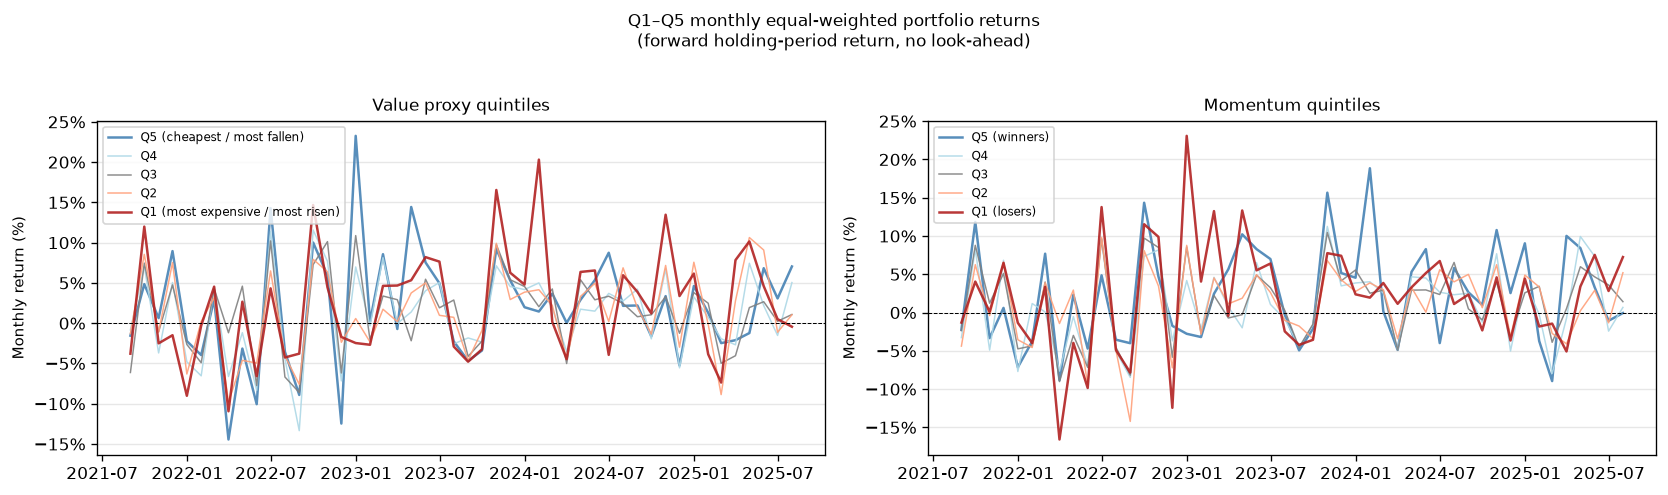

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, q_df, title, q5_label, q1_label in [
    (axes[0], val_q, "Value proxy quintiles",
     "Q5 (cheapest / most fallen)", "Q1 (most expensive / most risen)"),
    (axes[1], mom_q, "Momentum quintiles",
     "Q5 (winners)", "Q1 (losers)"),
]:
    for q, color, label, lw in [
        (5, "steelblue",  q5_label, 1.5),
        (4, "lightblue",  "Q4",  0.9),
        (3, "gray",       "Q3",  0.9),
        (2, "lightsalmon","Q2",  0.9),
        (1, "firebrick",  q1_label, 1.5),
    ]:
        ts = q_df[q_df["quintile"] == q].set_index("date")["portfolio_return"]
        ax.plot(ts.index, ts * 100, color=color, linewidth=lw, label=label, alpha=0.9)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Monthly return (%)", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Q1–Q5 monthly equal-weighted portfolio returns\n"
             "(forward holding-period return, no look-ahead)", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig("quintile_monthly_returns.png", bbox_inches="tight")
plt.show()

## 12 · Quality checklist

| Check | Status |
|---|---|
| Quintile assignment by rank position (`np.array_split`), not raw score cutoffs — sizes documented | ✓ 51-ticker: [11,10,10,10,10]; 50-ticker: [10,10,10,10,10] |
| Q5 = highest score = most desirable; Q1 = lowest — verified with PLTR | ✓ PLTR in value Q1, momentum Q5 |
| Forward return at `t` = return from `t` to `t+1` — shift(-1) verified with manual spot-check | ✓ AAPL at 2021-09-30: correct=+5.87%, wrong=−6.80% |
| Simple returns used for equal-weight average within quintile | ✓ |
| Last rebalance date (2025-08-31) excluded — no forward return period | ✓ logged |
| `form_quintile_portfolios` is signal-agnostic; same function used for both factors | ✓ |
| Notebook runs top-to-bottom with Restart Kernel & Run All | ✓ |